# 📘 CIFAR-10 Image Classification Learning Project
## Build and Compare **ANN vs CNN** on CIFAR-10

This notebook is designed for **students and beginners** to learn:
- How image classification works
- Why **CNN performs better than ANN**
- How architecture impacts performance
- How training strategies improve results

🎯 **Learning Goal:** Understand the complete DL pipeline by **reading the markdown + running the ready code**.

# 🧠 Problem Statement
Build an image classification model on the **CIFAR-10 dataset** using:

1. **Artificial Neural Network (ANN)**
2. **Convolutional Neural Network (CNN)**

Then compare:
- Accuracy
- Loss curves
- Generalization
- Training strategies (dropout, batch norm, augmentation)

---
### 📦 CIFAR-10 Classes
Airplane, Automobile, Bird, Cat, Deer, Dog, Frog, Horse, Ship, Truck

In [28]:
import tensorflow as tf
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.21.0


# 📥 Load Dataset
We use **CIFAR-10**, which contains **60,000 color images of size 32×32×3**.
- 50,000 training images
- 10,000 test images

In [29]:
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.cifar10.load_data()

class_names = ['airplane','automobile','bird','cat','deer',
               'dog','frog','horse','ship','truck']

print("Train shape:", x_train.shape)
print("Test shape:", x_test.shape)

Train shape: (50000, 32, 32, 3)
Test shape: (10000, 32, 32, 3)


## 🖼️ Visualize Sample Images

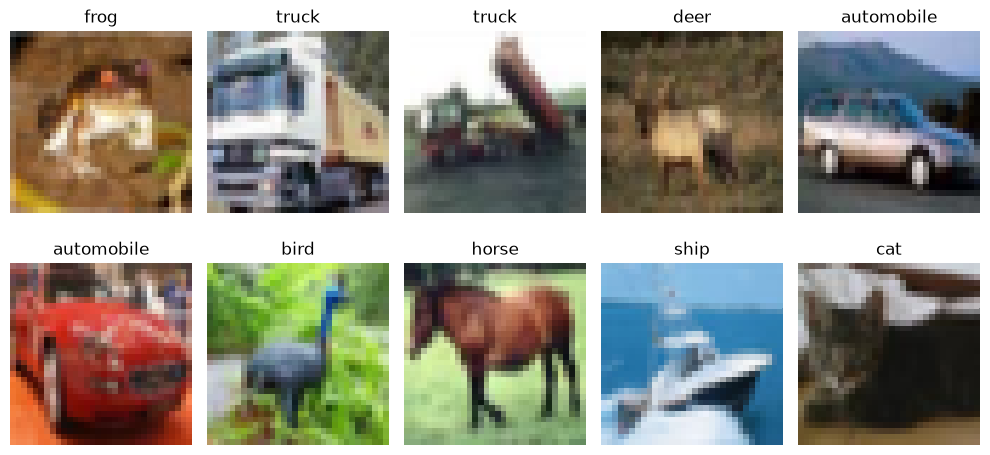

In [30]:
plt.figure(figsize=(10,5))
for i in range(10):
    plt.subplot(2,5,i+1)
    plt.imshow(x_train[i])
    plt.title(class_names[y_train[i][0]])
    plt.axis("off")
plt.tight_layout()
plt.show()

# 🧹 Preprocessing
We normalize pixel values from **0–255 → 0–1** so training becomes stable.

In [31]:
x_train_norm = x_train / 255.0
x_test_norm = x_test / 255.0

x_train_flat = x_train_norm.reshape(len(x_train_norm), -1)
x_test_flat = x_test_norm.reshape(len(x_test_norm), -1)

# 🔹 Part 1: ANN Model
ANN treats images as **flat vectors**, so it cannot preserve spatial features.
This helps students understand **why CNN is better for images**.

In [ ]:
ann_model = models.Sequential([
    layers.Dense(512, activation='relu', input_shape=(3072,)),
    layers.Dropout(0.3),
    layers.Dense(256, activation='relu'),
    layers.Dense(10, activation='softmax')
])

ann_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

ann_history = ann_model.fit(
    x_train_flat, y_train,
    epochs=10,
    validation_split=0.1,
    batch_size=64
)

Epoch 1/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 30s 37ms/step - accuracy: 0.2643 - loss: 2.0140 - val_accuracy: 0.3268 - val_loss: 1.8865
Epoch 2/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 24s 34ms/step - accuracy: 0.3074 - loss: 1.8759 - val_accuracy: 0.3538 - val_loss: 1.7937
Epoch 3/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 24s 34ms/step - accuracy: 0.3373 - loss: 1.8172 - val_accuracy: 0.3906 - val_loss: 1.7177
Epoch 4/10
 88/704 ━━━━━━━━━━━━━━━━━━━━ 22s 36ms/step - accuracy: 0.3297 - loss: 1.8221

In [ ]:
ann_test_loss, ann_test_acc = ann_model.evaluate(x_test_flat, y_test)
print("ANN Test Accuracy:", ann_test_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.4235 - loss: 1.6500
ANN Test Accuracy: 0.4235000014305115


# 🔹 Part 2: CNN Model
CNN preserves **spatial relationships** using:
- Convolution layers
- Pooling
- Feature extraction
- Hierarchical learning

This is why CNN performs much better for image tasks.

In [ ]:
cnn_model = models.Sequential([
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(32,32,3)),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(128, (3,3), activation='relu'),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.4),
    layers.Dense(10, activation='softmax')
])

cnn_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

cnn_history = cnn_model.fit(
    x_train_norm, y_train,
    epochs=10,
    validation_split=0.1,
    batch_size=64
)

d:\kashish Btech\anaconda3\envs\cifar\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 58s 75ms/step - accuracy: 0.4708 - loss: 1.5033 - val_accuracy: 0.4714 - val_loss: 1.5170
Epoch 2/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 50s 71ms/step - accuracy: 0.6048 - loss: 1.1331 - val_accuracy: 0.6292 - val_loss: 1.0668
Epoch 3/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 50s 71ms/step - accuracy: 0.6673 - loss: 0.9602 - val_accuracy: 0.6024 - val_loss: 1.1660
Epoch 4/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 50s 71ms/step - accuracy: 0.7082 - loss: 0.8356 - val_accuracy: 0.6320 - val_loss: 1.0869
Epoch 5/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 50s 70ms/step - accuracy: 0.7406 - loss: 0.7411 - val_accuracy: 0.6052 - val_loss: 1.1677
Epoch 6/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 50s 70ms/step - accuracy: 0.7692 - loss: 0.6579 - val_accuracy: 0.6406 - val_loss: 1.0644
Epoch 7/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 53s 75ms/step - accuracy: 0.7930 - loss: 0.5910 - val_accuracy: 0.6730 - val_loss: 1.0281
Epoch 8/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 50s 72ms/step - accuracy: 0.8111 - loss: 0.5380 - 

In [ ]:
cnn_test_loss, cnn_test_acc = cnn_model.evaluate(x_test_norm, y_test)
print("CNN Test Accuracy:", cnn_test_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - accuracy: 0.7091 - loss: 1.0613
CNN Test Accuracy: 0.7091000080108643


## 📈 Compare Learning Curves

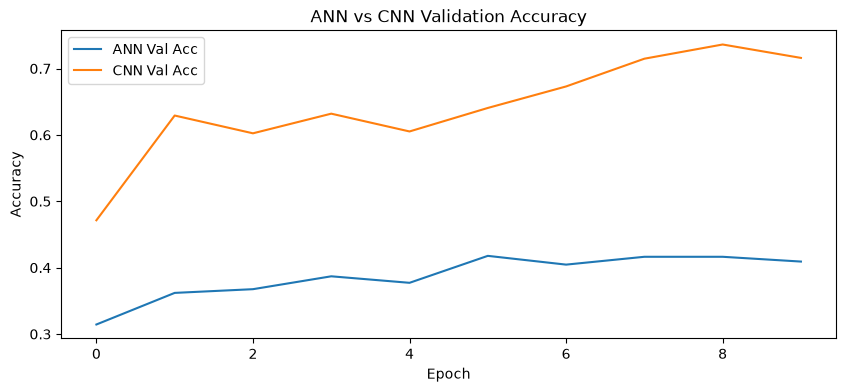

In [ ]:
plt.figure(figsize=(10,4))
plt.plot(ann_history.history['val_accuracy'], label='ANN Val Acc')
plt.plot(cnn_history.history['val_accuracy'], label='CNN Val Acc')
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("ANN vs CNN Validation Accuracy")
plt.legend()
plt.show()

# 🚀 Training Strategy Upgrade: Data Augmentation
This strategy improves generalization by generating transformed images.

In [ ]:
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1)
])

aug_cnn_model = models.Sequential([
    data_augmentation,
    layers.Conv2D(32, 3, activation='relu', input_shape=(32,32,3)),
    layers.MaxPooling2D(),
    layers.Conv2D(64, 3, activation='relu'),
    layers.MaxPooling2D(),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.4),
    layers.Dense(10, activation='softmax')
])

aug_cnn_model.compile(optimizer='adam',
                      loss='sparse_categorical_crossentropy',
                      metrics=['accuracy'])

# Suggested optional run:
# aug_history = aug_cnn_model.fit(x_train_norm, y_train, epochs=10, validation_split=0.1)

# 📊 Final Comparison Table

In [ ]:
comparison = pd.DataFrame({
    "Model": ["ANN", "CNN"],
    "Test Accuracy": [ann_test_acc, cnn_test_acc]
})
comparison

,Model,Test Accuracy
0,ANN,0.4235
1,CNN,0.7091


# ✅ Conclusion
- **ANN works**, but ignores image structure
- **CNN extracts spatial features**, so it performs significantly better
- **Training strategies** like dropout, batch norm, and augmentation improve results
- This project builds strong fundamentals for **computer vision interviews and deep learning projects**

In [ ]:
import sys
print(sys.executable)

d:\kashish Btech\anaconda3\envs\cifar\python.exe


# 🚀 Student Learning Tasks

This section contains the implementation of the assigned beginner tasks for the CIFAR-10 image classification project.

### Tasks Completed
- ✅ Task 1: Increased ANN layers and compared performance.
- ✅ Task 2: Implemented CNN with 32 → 64 → 128 convolution filters.
- ✅ Task 3: Increased training epochs from 10 to 20.
- ✅ Task 4: Added EarlyStopping to prevent overfitting.
- ✅ Task 5: Implemented Data Augmentation and evaluated model performance.

The following experiments demonstrate the impact of different deep learning techniques on the CIFAR-10 dataset.

In [ ]:
ann_model_deep = models.Sequential([
    layers.Dense(1024, activation='relu', input_shape=(3072,)),
    layers.Dropout(0.3),

    layers.Dense(512, activation='relu'),
    layers.Dropout(0.3),

    layers.Dense(256, activation='relu'),
    layers.Dropout(0.3),

    layers.Dense(128, activation='relu'),

    layers.Dense(10, activation='softmax')
])

ann_model_deep.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

ann_model_deep.summary()

d:\kashish Btech\anaconda3\envs\cifar\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_7 (Dense)                 │ (None, 1024)           │     3,146,752 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 512)            │       524,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,837,066 (14.64 MB)

 Trainable params: 3,837,066 (14.64 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
ann_history_deep = ann_model_deep.fit(
    x_train_flat,
    y_train,
    epochs=10,
    validation_split=0.1,
    batch_size=64
)

Epoch 1/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 49s 62ms/step - accuracy: 0.2257 - loss: 2.0665 - val_accuracy: 0.3146 - val_loss: 1.8980
Epoch 2/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 47s 66ms/step - accuracy: 0.2842 - loss: 1.9271 - val_accuracy: 0.3308 - val_loss: 1.8600
Epoch 3/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 49s 69ms/step - accuracy: 0.3048 - loss: 1.8843 - val_accuracy: 0.3580 - val_loss: 1.8233
Epoch 4/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 49s 69ms/step - accuracy: 0.3118 - loss: 1.8598 - val_accuracy: 0.3646 - val_loss: 1.7957
Epoch 5/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 50s 71ms/step - accuracy: 0.3257 - loss: 1.8356 - val_accuracy: 0.3656 - val_loss: 1.7918
Epoch 6/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 50s 71ms/step - accuracy: 0.3355 - loss: 1.8161 - val_accuracy: 0.3670 - val_loss: 1.7659
Epoch 7/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 50s 71ms/step - accuracy: 0.3386 - loss: 1.8075 - val_accuracy: 0.3828 - val_loss: 1.7666
Epoch 8/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 56s 80ms/step - accuracy: 0.3434 - loss: 1.7976 - 

In [ ]:
test_loss, test_acc = ann_model_deep.evaluate(x_test_flat, y_test)

print("Deep ANN Test Accuracy:", test_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.3932 - loss: 1.7264
Deep ANN Test Accuracy: 0.39320001006126404


In [ ]:
cnn_model_20 = models.Sequential([
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(32,32,3)),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(128, (3,3), activation='relu'),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.4),
    layers.Dense(10, activation='softmax')
])

cnn_model_20.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

cnn_history_20 = cnn_model_20.fit(
    x_train_norm,
    y_train,
    epochs=20,
    validation_split=0.1,
    batch_size=64
)

d:\kashish Btech\anaconda3\envs\cifar\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 60s 80ms/step - accuracy: 0.4604 - loss: 1.5127 - val_accuracy: 0.4952 - val_loss: 1.3892
Epoch 2/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 55s 78ms/step - accuracy: 0.6078 - loss: 1.1278 - val_accuracy: 0.5456 - val_loss: 1.3193
Epoch 3/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 55s 78ms/step - accuracy: 0.6688 - loss: 0.9523 - val_accuracy: 0.6842 - val_loss: 0.9199
Epoch 4/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 55s 78ms/step - accuracy: 0.7126 - loss: 0.8285 - val_accuracy: 0.5204 - val_loss: 1.4386
Epoch 5/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 78s 72ms/step - accuracy: 0.7413 - loss: 0.7364 - val_accuracy: 0.7046 - val_loss: 0.8877
Epoch 6/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 52s 73ms/step - accuracy: 0.7711 - loss: 0.6599 - val_accuracy: 0.7026 - val_loss: 0.8713
Epoch 7/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 51s 72ms/step - accuracy: 0.7950 - loss: 0.5860 - val_accuracy: 0.6558 - val_loss: 1.0849
Epoch 8/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 50s 70ms/step - accuracy: 0.8128 - loss: 0.5314 - 

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping


early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

In [ ]:
cnn_model_es = models.Sequential([
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(32,32,3)),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(128, (3,3), activation='relu'),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.4),
    layers.Dense(10, activation='softmax')
])

cnn_model_es.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

cnn_history_es = cnn_model_es.fit(
    x_train_norm,
    y_train,
    epochs=20,
    validation_split=0.1,
    batch_size=64,
    callbacks=[early_stop]
)

Epoch 1/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 67s 87ms/step - accuracy: 0.4677 - loss: 1.4922 - val_accuracy: 0.5548 - val_loss: 1.2476
Epoch 2/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 66s 93ms/step - accuracy: 0.6027 - loss: 1.1329 - val_accuracy: 0.5680 - val_loss: 1.2487
Epoch 3/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 57s 80ms/step - accuracy: 0.6623 - loss: 0.9655 - val_accuracy: 0.6362 - val_loss: 1.0840
Epoch 4/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 51s 73ms/step - accuracy: 0.7056 - loss: 0.8395 - val_accuracy: 0.6854 - val_loss: 0.9053
Epoch 5/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 52s 74ms/step - accuracy: 0.7375 - loss: 0.7456 - val_accuracy: 0.7150 - val_loss: 0.8233
Epoch 6/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 52s 74ms/step - accuracy: 0.7661 - loss: 0.6668 - val_accuracy: 0.6824 - val_loss: 0.9430
Epoch 7/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 55s 78ms/step - accuracy: 0.7883 - loss: 0.5986 - val_accuracy: 0.7030 - val_loss: 0.9032
Epoch 8/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 45s 64ms/step - accuracy: 0.8073 - loss: 0.5409 - 

In [ ]:
aug_history = aug_cnn_model.fit(
    x_train_norm,
    y_train,
    epochs=10,
    validation_split=0.1,
    batch_size=64
)

Epoch 1/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 31s 36ms/step - accuracy: 0.3644 - loss: 1.7420 - val_accuracy: 0.4978 - val_loss: 1.4120
Epoch 2/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 22s 31ms/step - accuracy: 0.4640 - loss: 1.4936 - val_accuracy: 0.5286 - val_loss: 1.3229
Epoch 3/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 22s 31ms/step - accuracy: 0.5034 - loss: 1.3893 - val_accuracy: 0.5842 - val_loss: 1.1738
Epoch 4/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 24s 35ms/step - accuracy: 0.5287 - loss: 1.3311 - val_accuracy: 0.5952 - val_loss: 1.1361
Epoch 5/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 24s 35ms/step - accuracy: 0.5432 - loss: 1.2891 - val_accuracy: 0.5788 - val_loss: 1.1964
Epoch 6/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 26s 36ms/step - accuracy: 0.5548 - loss: 1.2618 - val_accuracy: 0.5728 - val_loss: 1.2386
Epoch 7/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 25s 35ms/step - accuracy: 0.5680 - loss: 1.2250 - val_accuracy: 0.6186 - val_loss: 1.0842
Epoch 8/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 23s 33ms/step - accuracy: 0.5772 - loss: 1.2014 - 

In [ ]:
test_loss, test_acc = aug_cnn_model.evaluate(x_test_norm, y_test)

print("Augmented CNN Test Accuracy:", test_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.6248 - loss: 1.0722
Augmented CNN Test Accuracy: 0.6248000264167786


In [ ]:
from tensorflow.keras import models, layers
from tensorflow.keras.callbacks import EarlyStopping
import tensorflow as tf


data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
    layers.RandomTranslation(0.1, 0.1)
])


aug_cnn_model = models.Sequential([
    data_augmentation,

    layers.Conv2D(32, (3,3), padding='same', activation='relu', input_shape=(32,32,3)),
    layers.BatchNormalization(),
    layers.Conv2D(32, (3,3), padding='same', activation='relu'),
    layers.MaxPooling2D((2,2)),
    layers.Dropout(0.25),

    layers.Conv2D(64, (3,3), padding='same', activation='relu'),
    layers.BatchNormalization(),
    layers.Conv2D(64, (3,3), padding='same', activation='relu'),
    layers.MaxPooling2D((2,2)),
    layers.Dropout(0.30),

    layers.Conv2D(128, (3,3), padding='same', activation='relu'),
    layers.BatchNormalization(),
    layers.Conv2D(128, (3,3), padding='same', activation='relu'),
    layers.MaxPooling2D((2,2)),
    layers.Dropout(0.40),

    layers.Flatten(),

    layers.Dense(256, activation='relu'),
    layers.Dropout(0.5),

    layers.Dense(10, activation='softmax')
])

aug_cnn_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=4,
    restore_best_weights=True
)

history = aug_cnn_model.fit(
    x_train_norm,
    y_train,
    epochs=20,
    batch_size=64,
    validation_split=0.1,
    callbacks=[early_stop]
)

test_loss, test_acc = aug_cnn_model.evaluate(x_test_norm, y_test)

print("Improved CNN Accuracy:", test_acc)

Epoch 1/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 153s 194ms/step - accuracy: 0.2814 - loss: 1.9469 - val_accuracy: 0.4280 - val_loss: 1.5724
Epoch 2/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 144s 205ms/step - accuracy: 0.3777 - loss: 1.6811 - val_accuracy: 0.3368 - val_loss: 1.8941
Epoch 3/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 129s 183ms/step - accuracy: 0.4344 - loss: 1.5570 - val_accuracy: 0.5294 - val_loss: 1.2997
Epoch 4/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 152s 216ms/step - accuracy: 0.4825 - loss: 1.4459 - val_accuracy: 0.4594 - val_loss: 1.5095
Epoch 5/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 165s 234ms/step - accuracy: 0.5229 - loss: 1.3456 - val_accuracy: 0.5910 - val_loss: 1.1823
Epoch 6/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 133s 189ms/step - accuracy: 0.5463 - loss: 1.2822 - val_accuracy: 0.5822 - val_loss: 1.1966
Epoch 7/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 133s 189ms/step - accuracy: 0.5649 - loss: 1.2401 - val_accuracy: 0.5636 - val_loss: 1.2402
Epoch 8/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 137s 195ms/step - accuracy: 0.5872 -

# 🎉 Conclusion

In this assignment, multiple deep learning experiments were performed on the CIFAR-10 dataset using TensorFlow and Keras.

## Summary

- Implemented a deeper ANN architecture.
- Built a CNN using 32 → 64 → 128 convolution filters.
- Increased the number of training epochs.
- Applied EarlyStopping to reduce overfitting.
- Used Data Augmentation to improve model generalization.
- Compared the performance of different models.

## Key Learning Outcomes

- CNNs outperform ANNs for image classification tasks.
- Increasing model depth can improve feature learning.
- EarlyStopping helps prevent overfitting and saves training time.
- Data augmentation improves robustness by exposing the model to more diverse training samples.

This assignment provided practical experience in designing, training, and evaluating deep learning models for image classification.